# cu_inj Impact-T phasing and scaling

In [1]:
# Useful for debugging
%load_ext autoreload
%autoreload 2

%pylab --no-import-all inline
%config InlineBackend.figure_format = 'retina'

Populating the interactive namespace from numpy and matplotlib


In [2]:
from impact import Impact
from distgen import Generator

import os 

ROOT = os.environ['LCLS_LATTICE']

In [3]:
ifile = os.path.join(ROOT, 'impact/models/cu_inj/v0/ImpactT.yaml')
gfile = os.path.join(ROOT, 'distgen/models/cu_inj/v0/distgen.yaml')
assert os.path.exists(ifile)
assert os.path.exists(gfile)


In [4]:
I = Impact.from_yaml(ifile)

In [5]:
klist =  ['QA01:b1_gradient',
 'QA02:b1_gradient',
 'QE01:b1_gradient',
 'QE02:b1_gradient',
 'QE03:b1_gradient',
 'QE04:b1_gradient']
for k in klist:
    print(k, I[k])

QA01:b1_gradient 1.8524000101358
QA02:b1_gradient -1.8524000101358
QE01:b1_gradient 0.18720000156206
QE02:b1_gradient 0.16609999999321
QE03:b1_gradient -2.6409000012747
QE04:b1_gradient 2.9799999853198


In [6]:
# Check locations
for ele in I.lattice:
    if ele['type'] != 'quadrupole':
        continue
    name = ele['name']
    L = ele['L']
    L_eff = ele['L_effective']
    zedge = ele['zedge']
    sbeg = zedge + (L-L_eff)/2
    send = zedge + L - (L-L_eff)/2
    offset = 2017.91148
    print(f'{name} {L:10} {L_eff:10} {sbeg:10.6} {send:10.6}')

SQ01       0.36       0.21    0.09101    0.30101
CQ01       0.36       0.21    0.09101    0.30101
QA01      0.204      0.108    4.80093    4.90893
QA02      0.204      0.108    5.12931    5.23731
QE01      0.204      0.108    8.44005    8.54805
QE02      0.204      0.108    8.84156    8.94956
QE03      0.204      0.108    11.5172    11.6252
QE04      0.204      0.108    11.9236    12.0316


In [7]:
from impact.lattice import ele_line
ele_line(I.lattice[-1])

'0 0 0 -99 16.5 0.0 16.5 /!name:stop_1'

# Check Energies

In [8]:
from impact.autophase import autophase_and_scale

from pmd_beamphysics import single_particle

P0 = single_particle(pz=1e-15, z=1e-15)

# Energy out of the gun
I.track(P0, s = 0.5)['mean_energy']

6000000.000536164

In [9]:
I.track(P0, s = I['L0A_exit']['s'])['mean_energy']

63921961.54226266

In [10]:
I.track(P0, s = I['OTR2']['s'])['mean_energy']

133884464.87040418

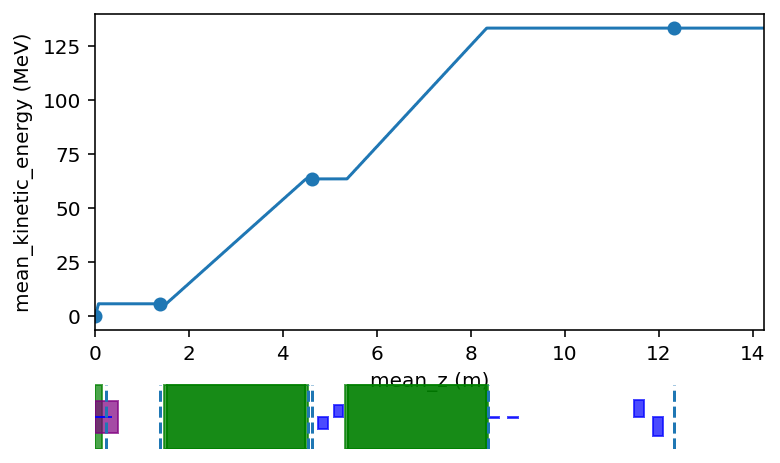

In [11]:
I.plot('mean_kinetic_energy')

In [12]:
I.particles

{'final_particles': <ParticleGroup with 1 particles at 0x2aaad6a40760>,
 'initial_particles': <ParticleGroup with 1 particles at 0x2aaad6a86e50>,
 'YAG02': <ParticleGroup with 1 particles at 0x2aaad6a86e80>,
 'YAG03': <ParticleGroup with 1 particles at 0x2aaad69ea0a0>,
 'OTR1': <ParticleGroup with 1 particles at 0x2aaad69ea190>,
 'OTR2': <ParticleGroup with 1 particles at 0x2aaad69ea700>}

In [13]:
I.header['Tini']

0

# Gun Phasing

In [14]:
autophase_and_scale(I, phase_ele_name='GUN_phase', phase_attribute='dtheta0_deg', scale_ele_name='GUN_scale', scale_attribute='voltage', target=6e6, scale_range=(4e6, 6e6), metric='mean_energy', initial_particles=P0, verbose=True)

Copied initial Impact object. 
Phasing GUN_phase by changing dtheta0_deg
Scaling GUN_scale by changing voltage
Bounds: 0.0, 0.15 m
Disabling SOL1
Disabling L0A_entrance
Disabling L0A_body_1
Disabling L0A_body_2
Disabling L0A_exit
Disabling L0B_entrance
Disabling L0B_body_1
Disabling L0B_body_2
Disabling L0B_exit
Default brent2 algorithm
Phase: 180, Scale: 4000000.0, 0.0 M
Phase: 180, Scale: 4000000.0, 0.0 M
Phase: 42.49224000000004, Scale: 4000000.0, 3.3187678203780315 MeV
Phase: 264.9844890561601, Scale: 4000000.0, 0.0 M
Phase: 42.49224000000004, Scale: 4000000.0, 3.3187678203780315 MeV
Phase: 42.49223440298533, Scale: 4000000.0, 3.318768120421592 MeV
Phase: 264.9844709438398, Scale: 4000000.0, 0.0 M
Phase: 222.49225347495212, Scale: 4000000.0, 0.0 M
Phase: 127.47670402554945, Scale: 4000000.0, 0.0 M
Phase: 333.7383616878283, Scale: 4000000.0, 4.4316522234874265 MeV
Phase: 291.24613071818885, Scale: 4000000.0, 0.0 M
Phase: 3.4333459097979357e-06, Scale: 4000000.0, 4.466519626613704 Me

(0.07752968240851033, 5489005.283048258)

# L0A, L0B

In [15]:
# L0A
autophase_and_scale(I, phase_ele_name='L0A_phase', phase_attribute='dtheta0_deg', scale_ele_name='L0A_scale', scale_attribute='voltage',
                    target=64e6, scale_range=(10e6, 100e6), initial_particles=P0, verbose=True, debug=False)

Copied initial Impact object. 
Phasing L0A_phase by changing dtheta0_deg
Scaling L0A_scale by changing voltage
Bounds: 1.485, 4.527856 m
Tracking initial particles to s = 1.485
Initial particle:  1.48536675856 6000000.000077931
Disabling GUN
Disabling SOL1
Disabling L0B_entrance
Disabling L0B_body_1
Disabling L0B_body_2
Disabling L0B_exit
Default brent2 algorithm
Phase: 180, Scale: 10000000.0, 5.671562500984266 MeV
Phase: 180, Scale: 10000000.0, 5.671562500984266 MeV
Phase: 42.49224000000004, Scale: 10000000.0, 12.368947690263361 MeV
Phase: 264.9844890561601, Scale: 10000000.0, 7.737540181994449 MeV
Phase: 42.49224000000004, Scale: 10000000.0, 12.368947690263361 MeV
Phase: 42.49223440298533, Scale: 10000000.0, 12.368948502220814 MeV
Phase: 264.9844709438398, Scale: 10000000.0, 7.737537971419893 MeV
Phase: 222.4922687582564, Scale: 10000000.0, 4.761755265574722 MeV
Phase: 127.47670402554945, Scale: 10000000.0, 4.123910287524997 MeV
Phase: 333.73836752553075, Scale: 10000000.0, 15.404731

(0.013456889405006223, 57999991.29704599)

In [16]:
ps_f, Itest = autophase_and_scale(I, phase_ele_name='L0A_phase', phase_attribute='dtheta0_deg', scale_ele_name='L0A_scale', scale_attribute='voltage',
                    target=64e6, scale_range=(10e6, 100e6), initial_particles=P0, verbose=True, debug=True)

Copied initial Impact object. 
Phasing L0A_phase by changing dtheta0_deg
Scaling L0A_scale by changing voltage
Bounds: 1.485, 4.527856 m
Tracking initial particles to s = 1.485
Initial particle:  1.48536675856 6000000.000077931
Disabling GUN
Disabling SOL1
Disabling L0B_entrance
Disabling L0B_body_1
Disabling L0B_body_2
Disabling L0B_exit


In [17]:
Itest.header['Tini']

0

Phase: -2.0, Scale: 58000000.0, 63.964903733750305 MeV
Phase: -1.5, Scale: 58000000.0, 63.98026206880593 MeV
Phase: -1.0, Scale: 58000000.0, 63.99123477912476 MeV
Phase: -0.5, Scale: 58000000.0, 63.99781636172542 MeV
Phase: 0.0, Scale: 58000000.0, 64.00000164684869 MeV
Phase: 0.5, Scale: 58000000.0, 63.997785801023625 MeV
Phase: 1.0, Scale: 58000000.0, 63.991164322468876 MeV
Phase: 1.5, Scale: 58000000.0, 63.98013304262586 MeV
Phase: 2.0, Scale: 58000000.0, 63.96468812258206 MeV


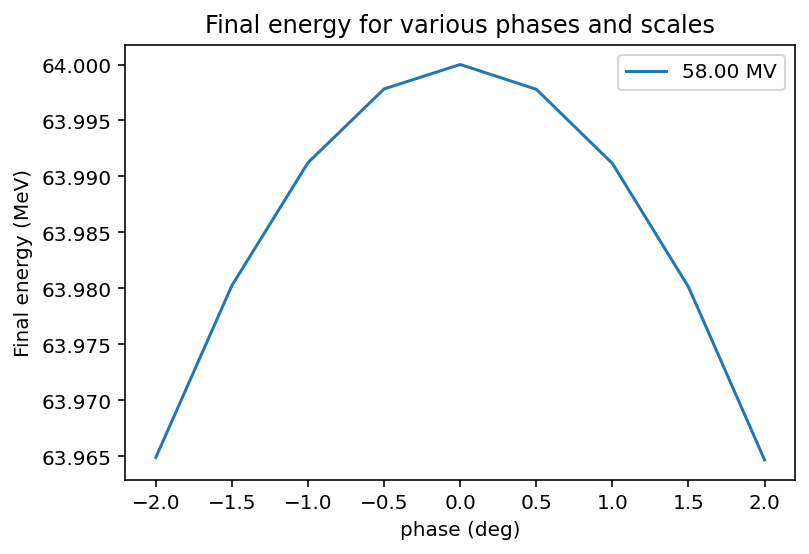

In [18]:
# Phases to try
ptry = np.linspace(-2, 2, 9)

# scales to try
sc = 58e6
res = np.array([ps_f(p, sc)/1e6 for p in ptry])
plt.plot(ptry, res, label=f'{sc/1e6:0.2f} MV')
plt.title('Final energy for various phases and scales')
plt.ylabel('Final energy (MeV)')
plt.xlabel('phase (deg)')
plt.legend()

In [19]:
# Get scale/voltage factor
30048347.359377533/(64e6 - 6e6) * np.array( [0.86571945106805, 1, 1, 0.86571945106805])

array([0.44850757, 0.51807495, 0.51807495, 0.44850757])

In [20]:
I = Impact.from_yaml(ifile)
I.group['L0B_scale']

ControlGroup(**{"ele_names": ["L0B_entrance", "L0B_body_1", "L0B_body_2", "L0B_exit"], "var_name": "voltage", "attributes": ["rf_field_scale", "rf_field_scale", "rf_field_scale", "rf_field_scale"], "factors": [0.44850757, 0.51807495, 0.51807495, 0.44850757], "reference_values": [31841617.97938928, 36780527.3869102, 36780527.3869102, 31841617.97938928], "absolute": true, "value": 70000000.0})

In [21]:
autophase_and_scale(I, phase_ele_name='L0B_phase', phase_attribute='dtheta0_deg', scale_ele_name='L0B_scale', scale_attribute='voltage', target=135e6, scale_range=(10e6, 100e6), initial_particles=P0, verbose=True)

Copied initial Impact object. 
Phasing L0B_phase by changing dtheta0_deg
Scaling L0B_scale by changing voltage
Bounds: 5.328756, 8.371612 m
Tracking initial particles to s = 5.328756
Initial particle:  5.32887894282 63921961.54226266
Disabling GUN
Disabling SOL1
Disabling L0A_entrance
Disabling L0A_body_1
Disabling L0A_body_2
Disabling L0A_exit
Default brent2 algorithm
Phase: 180, Scale: 10000000.0, 53.92196524230732 MeV
Phase: 180, Scale: 10000000.0, 53.92196524230732 MeV
Phase: 42.49224000000004, Scale: 10000000.0, 71.28907933537562 MeV
Phase: 264.9844890561601, Scale: 10000000.0, 63.06222180835335 MeV
Phase: 42.49224000000004, Scale: 10000000.0, 71.28907933537562 MeV
Phase: 42.49223440298533, Scale: 10000000.0, 71.28907999608812 MeV
Phase: 264.9844709438398, Scale: 10000000.0, 63.06221865964393 MeV
Phase: 222.4922516575823, Scale: 10000000.0, 56.55929655241025 MeV
Phase: 127.47670402554945, Scale: 10000000.0, 57.82549278689085 MeV
Phase: 333.7383609936546, Scale: 10000000.0, 72.8961

(359.9887569475918, 71072568.73563252)

# Integrated Solenoid field

In [22]:
from impact import  fieldmaps
import numpy as np

# Fieldmaps are stored here
I.input['fieldmaps'].keys()

dict_keys(['rfdata201', 'rfdata102', 'rfdata4', 'rfdata5', 'rfdata6', 'rfdata7'])

In [23]:
# Look at a solrf element. 
I.ele['SOL1']

{'description': 'name:SOL1',
 'original': '0.49308 0 0 105 0.0 0.0 0.0 0.0 102 0.15 0.0 0.0 0.0 0.0 0.0 0.2457 /!name:SOL1',
 'L': 0.49308,
 'type': 'solrf',
 'zedge': 0.0,
 'rf_field_scale': 0.0,
 'rf_frequency': 0.0,
 'theta0_deg': 0.0,
 'filename': 'rfdata102',
 'radius': 0.15,
 'x_offset': 0.0,
 'y_offset': 0.0,
 'x_rotation': 0.0,
 'y_rotation': 0.0,
 'z_rotation': 0.0,
 'solenoid_field_scale': 0.2457,
 's': 0.49308,
 'name': 'SOL1'}

In [24]:
# That data is here. 
rdfata = I.input['fieldmaps']['rfdata102']

#This will process the fieldmap to extract Ez and Bz
fmap = fieldmaps.process_fieldmap_solrf(rdfata['data'])
fmap

{'Ez': {'z0': 0.0, 'z1': 0.0, 'L': 0.0, 'fourier_coefficients': array([0.])},
 'Bz': {'z0': -0.53308,
  'z1': 0.49308,
  'L': 1.02616,
  'fourier_coefficients': array([ 7.59104159e-01,  1.86860998e-01,  2.68209187e-09, -4.75732117e-01,
          5.68488796e-09, -2.63303014e-01, -2.00685489e-10,  8.31385362e-02,
         -1.07061180e-09,  3.32147505e-02,  3.34109023e-09, -4.03166145e-03,
          2.36977653e-09,  7.55695585e-02,  7.03628508e-09,  4.05472421e-02,
         -7.93679210e-09, -2.78630279e-02, -2.80674359e-08, -1.23309101e-02,
         -1.21750197e-08, -1.11917490e-03,  2.72183881e-08, -1.76941899e-02,
          2.07775590e-08, -6.82928971e-03, -4.64611502e-09,  9.04327137e-03,
         -2.74644209e-08,  3.46208848e-03,  1.22819960e-08,  4.56318358e-04,
          2.11520498e-08,  4.27450120e-03, -2.88644504e-08,  7.52482987e-04,
         -3.59752217e-08, -2.87393685e-03,  1.26542743e-08, -8.38592686e-04,
          3.01815044e-08, -1.30737597e-04, -9.86177028e-09, -1.04357300

In [25]:
# Reconstruction function
fieldmaps.fieldmap_reconsruction(fmap['Bz'], 0)

0.006497827018878065

In [26]:
zmax = 0.49308

zlist = np.linspace(0, zmax, 1000)
fieldlist = np.array([fieldmaps.fieldmap_reconsruction(fmap['Bz'], z) for z in zlist])

# z at max field
zlist[np.argmax(np.array(fieldlist))]

0.19496156156156158

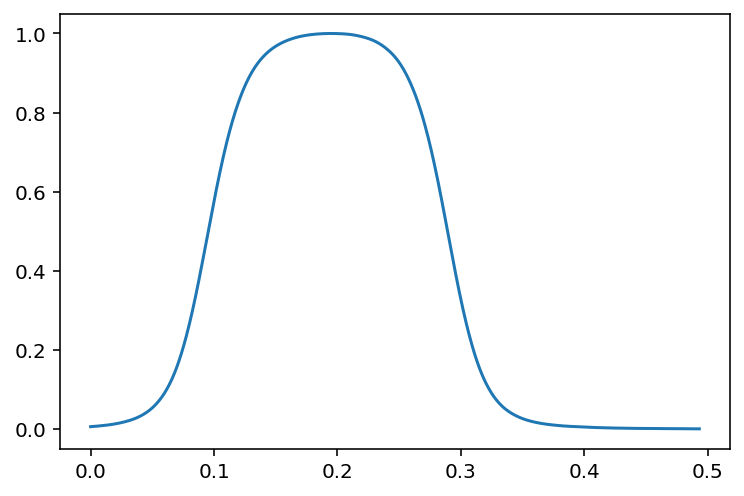

In [27]:
plt.plot(zlist, fieldlist)

In [28]:
# Effective length (integral of field^2)
Leff = np.trapz(fieldlist**2, zlist)/fieldlist.max()**2
Leff

0.16302677636670174

In [29]:
# PV (kG*m)/Leff*m * 0.1 T/kG = peak field in T

In [30]:
# Integrated field (approximate)
dz = zmax/1000
BL = np.sum(fieldlist)*dz  # T*m

# 
BL * 10 # T*m -> kG*m

1.9444947113581672

In [31]:
# Factor to convert BL in kG*m to Bmax in T
1/(BL * 10 )

0.5142724195436521

# Corrector Quads

In [32]:
ele = I.ele['CQ01']
ele

{'description': 'name:CQ01',
 'original': '0.36 0 0 1 0.01601  0.0 0.210 0.0254 0.0 0.0 0.0 0.0 0 /!name:CQ01',
 'L': 0.36,
 'type': 'quadrupole',
 'zedge': 0.01601,
 'b1_gradient': 0.0,
 'L_effective': 0.21,
 'radius': 0.0254,
 'x_offset': 0.0,
 'y_offset': 0.0,
 'x_rotation': 0.0,
 'y_rotation': 0.0,
 'z_rotation': 0.0,
 's': 0.37601,
 'name': 'CQ01'}

In [33]:
I['CQ01:b1_gradient']

0.0

In [34]:
# Factor to convert kG to T/m
0.1/ele['L_effective'] 

0.4761904761904762